In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import torch

from brain_image.model.comm.comm import CoMM
from brain_image.model.comm.encoders import AlexNetEncoder
from brain_image.model.comm.input_adapters import FeaturesInputAdapter, PatchedInputAdapter
from brain_image.model.comm.mmfusion import MMFusion
from brain_image.model.eeg_encoder.atms import AtmsEEGEncoder, AtmsEEGEncoderConfig
from brain_image.model.img_encoder import CLIPImageEncoder

from torch.utils.data import DataLoader
from pathlib import Path

from brain_image.data.things_eeg2_dataset import ThingsEEG2Dataset, ThingsEEG2DatasetConfig


/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadat

In [4]:
things_path = Path("data/things-eeg2")
dataset_config = ThingsEEG2DatasetConfig(subs=[1], num_workers=0)
dataset = ThingsEEG2Dataset(
    dataset_config, 
    split="test", 
)
loader = DataLoader(dataset, batch_size=4, num_workers=0)

In [5]:
from brain_image.data.data import batch_load_images, load_image_from_path


ex_batch = next(iter(loader))
img = batch_load_images(ex_batch["img_path"])
eeg = ex_batch["eeg_data"]

img = img.to(device="cuda", dtype=float)
eeg = eeg.to(device="cuda", dtype=float)

...;

In [6]:
comm = CoMM(
    encoder=MMFusion(
        encoders=[ # Symmetric visual encoders
            #AlexNetEncoder(latent_dim=512, global_pool=""), 
            CLIPImageEncoder(), # 1024
            AtmsEEGEncoder(AtmsEEGEncoderConfig(d_channels=63, d_output=768))
        ], 
        input_adapters=[ # Pach adapters for multimodal fusion
            FeaturesInputAdapter(768, 512),
            #PatchedInputAdapter(num_channels=256, stride_level=1, patch_size_full=1, dim_tokens=512, image_size=6),
            #PatchedInputAdapter(num_channels=256, stride_level=1, patch_size_full=1, dim_tokens=512, image_size=6)
            FeaturesInputAdapter(768, 512)
        ],
        embed_dim=512
    ),
    projection=CoMM._build_mlp(512, 512, 256),
    optim_kwargs=dict(lr=3e-4, weight_decay=1e-4),
    loss_kwargs=dict(temperature=0.1)
)
comm.to(device="cuda", dtype=float)

CoMM(
  (encoder): MMFusion(
    (input_adapters): ModuleList(
      (0-1): 2 x FeaturesInputAdapter()
    )
    (encoders): ModuleList(
      (0): CLIPImageEncoder(
        (model): CLIPVisionModelWithProjection(
          (vision_model): CLIPVisionTransformer(
            (embeddings): CLIPVisionEmbeddings(
              (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
              (position_embedding): Embedding(257, 1024)
            )
            (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (encoder): CLIPEncoder(
              (layers): ModuleList(
                (0-23): 24 x CLIPEncoderLayer(
                  (self_attn): CLIPAttention(
                    (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
                    (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
                    (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
               

In [7]:
from brain_image.model.img_encoder import CLIPImageEncoder


clip_enc = comm.encoder.encoders[0]  

i1 = clip_enc.preprocess(img)
c = clip_enc.model(i1)

c.last_hidden_state.shape

torch.Size([4, 257, 1024])

In [7]:
#comm.forward([imgs / 255., eeg], [imgs / 255., eeg])

with torch.no_grad():
    out = comm.forward([img, eeg], [img, eeg])

out.keys()

dict_keys(['aug1_embed', 'aug2_embed', 'prototype'])

In [8]:
from brain_image.model.comm.comm_loss import CoMMLoss


comm_loss = CoMMLoss()
comm_loss.to(device="cuda", dtype=float)

comm_loss(out)

{'loss': tensor(0.4869, device='cuda:0', dtype=torch.float64),
 'ssl_acc': tensor(91.6667, device='cuda:0'),
 'ssl_acc_0': tensor(100., device='cuda:0'),
 'ssl_acc_1': tensor(75., device='cuda:0'),
 'ssl_acc_2': tensor(100., device='cuda:0'),
 'ssl_loss_0': tensor(0.1579, device='cuda:0', dtype=torch.float64),
 'ssl_loss_1': tensor(1.0297, device='cuda:0', dtype=torch.float64),
 'ssl_loss_2': tensor(0.2730, device='cuda:0', dtype=torch.float64)}

In [ ]:
from brain_image.augment import EEGAugmentationPipeline, ImageAugmentationPipeline




img_aug1 = image_augmenter(img)
img_aug2 = image_augmenter(img)

In [14]:
I = torch.arange(eeg.size(2)).repeat(3, 1)
I.shape

torch.Size([3, 250])

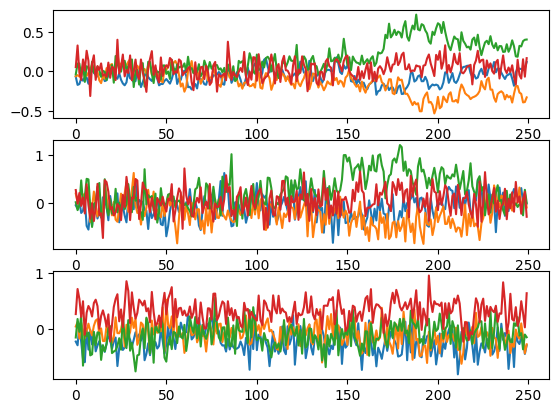

In [39]:
import matplotlib.pyplot as plt
import numpy as np


eeg_augmenter = EEGAugmentationPipeline()

eeg_aug1 = eeg_augmenter(eeg)
eeg_aug2 = eeg_augmenter(eeg)
C = 4
nC = 4
S = 0
I = torch.arange(eeg.size(2)).repeat(nC, 1)


plt.subplot(3, 1, 1)
plt.plot(I.T, eeg[S, C:C+nC].T.detach().cpu().numpy())
plt.subplot(3, 1, 2)
plt.plot(I.T,  eeg_aug1[S, C:C+nC].T.detach().cpu().numpy())
plt.subplot(3, 1, 3)
plt.plot(I.T,  eeg_aug2[S, C:C+nC].T.detach().cpu().numpy())
...;

tensor(0.0002, device='cuda:0', dtype=torch.float64) tensor(0.9996, device='cuda:0', dtype=torch.float64)
tensor(0.0002, device='cuda:0', dtype=torch.float64) tensor(0.9997, device='cuda:0', dtype=torch.float64)
torch.float64


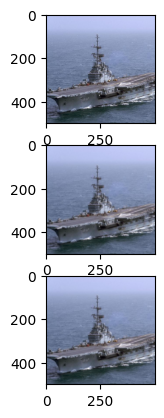

In [ ]:
import matplotlib.pyplot as plt 

image_augmenter = ImageAugmentationPipeline()

img_aug1 = image_augmenter(img)
img_aug2 = image_augmenter(img)

print(img[0].dtype)

plt.subplot(3, 1, 1)
plt.imshow((img[0] / 255.).permute(1, 2, 0).detach().cpu().numpy())
plt.subplot(3, 1, 2)
plt.imshow(img_aug1[0].permute(1, 2, 0).detach().cpu().numpy())
plt.subplot(3, 1, 3)
plt.imshow(img_aug2[0].permute(1, 2, 0).detach().cpu().numpy())

